In [16]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import Patch
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

In [17]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_raw = project_root / "data_raw"

week7_path = data_raw / "tokyo_features_v3_ols.geojson"
gdf = gpd.read_file(week7_path)

print(gdf.shape)
print(gdf.columns.tolist())
gdf.head()

(218, 10)
['N03_007', 'N03_001', 'N03_004', 'N03_005', 'foreign_ratio', 'log_dist_to_station_m', 'log_median_land_price_jpy', 'ols_fitted', 'ols_resid', 'geometry']


,N03_007,N03_001,N03_004,N03_005,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,ols_fitted,ols_resid,geometry
0,11101,埼玉県,さいたま市,西区,0.015422,7.105491,11.678448,0.030280,-0.014858,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,0.018455,5.933088,12.061053,0.036036,-0.017581,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,0.027177,2.982405,12.553206,0.047579,-0.020402,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,0.021768,6.913789,11.608245,0.030391,-0.008623,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,0.019989,4.556274,12.639480,0.043603,-0.023614,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


In [18]:
gdf["ols_resid"] = pd.to_numeric(gdf["ols_resid"], errors="coerce")
gdf["ols_resid"].describe()

count    2.180000e+02
mean     3.373958e-18
std      1.872014e-02
min     -2.656888e-02
25%     -1.223595e-02
50%     -4.442672e-03
75%      6.088973e-03
max      7.537033e-02
Name: ols_resid, dtype: float64

In [19]:
w = Queen.from_dataframe(gdf)
w.transform = "r"

print("Number of observations:", w.n)
print("Average neighbors:", w.mean_neighbors)

C:\Users\Jean\AppData\Local\Temp\ipykernel_15096\550500451.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


('WARNING: ', 78, ' is an island (no neighbors)')
Number of observations: 218
Average neighbors: 5.220183486238532


e:\rsch\laborJapan\geo_env\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 78.
  W.__init__(self, neighbors, ids=ids, **kw)


In [20]:
moran = Moran(gdf["ols_resid"], w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.37389508179005115
p-value: 0.001


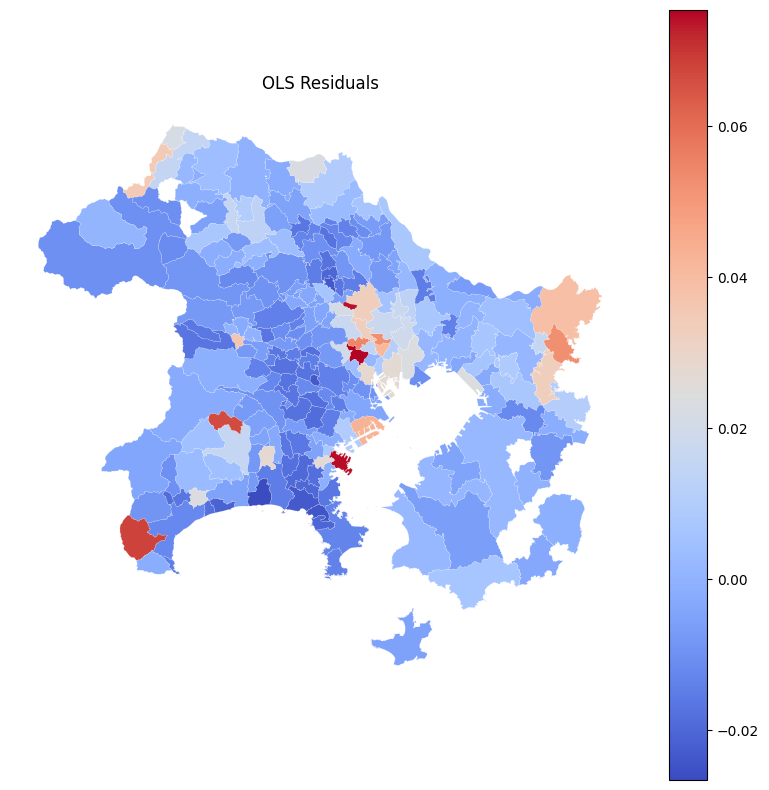

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="ols_resid",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title("OLS Residuals")
ax.set_axis_off()
plt.show()

In [22]:
print("Number of observations:", w.n)
print("Average neighbors:", w.mean_neighbors)

Number of observations: 218
Average neighbors: 5.220183486238532


In [23]:
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.37389508179005115
p-value: 0.001


## Global spatial autocorrelation of OLS residuals

The global Moran's I test on OLS residuals shows a statistically significant positive spatial autocorrelation (Moran's I = 0.374, p = 0.001).

This result indicates that the residuals are not randomly distributed across the Tokyo metropolitan mainland area. Instead, similar residual values tend to cluster spatially, suggesting that the baseline OLS model fails to capture important geographic structure.

Therefore, the residual diagnostics provide clear justification for moving beyond a global OLS specification and proceeding to local spatial diagnostics and spatially varying models.

In [24]:
lisa = Moran_Local(gdf["ols_resid"], w)

e:\rsch\laborJapan\geo_env\Lib\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


In [25]:
gdf["lisa_I"] = lisa.Is
gdf["lisa_p"] = lisa.p_sim
gdf["lisa_q"] = lisa.q

In [26]:
gdf["lisa_sig"] = gdf["lisa_p"] < 0.05
gdf["lisa_cluster"] = "Not significant"

In [27]:
gdf.loc[(gdf["lisa_q"] == 1) & (gdf["lisa_sig"]), "lisa_cluster"] = "High-High"
gdf.loc[(gdf["lisa_q"] == 2) & (gdf["lisa_sig"]), "lisa_cluster"] = "Low-High"
gdf.loc[(gdf["lisa_q"] == 3) & (gdf["lisa_sig"]), "lisa_cluster"] = "Low-Low"
gdf.loc[(gdf["lisa_q"] == 4) & (gdf["lisa_sig"]), "lisa_cluster"] = "High-Low"

In [28]:
gdf["lisa_cluster"].value_counts()

lisa_cluster
Not significant    158
Low-Low             38
High-High           21
High-Low             1
Name: count, dtype: int64

In [29]:
cluster_colors = {
    "Not significant": "lightgrey",
    "High-High": "red",
    "Low-Low": "blue",
    "Low-High": "lightblue",
    "High-Low": "salmon"
}

C:\Users\Jean\AppData\Local\Temp\ipykernel_15096\3455192384.py:13: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["lisa_cluster"] == cluster].plot(


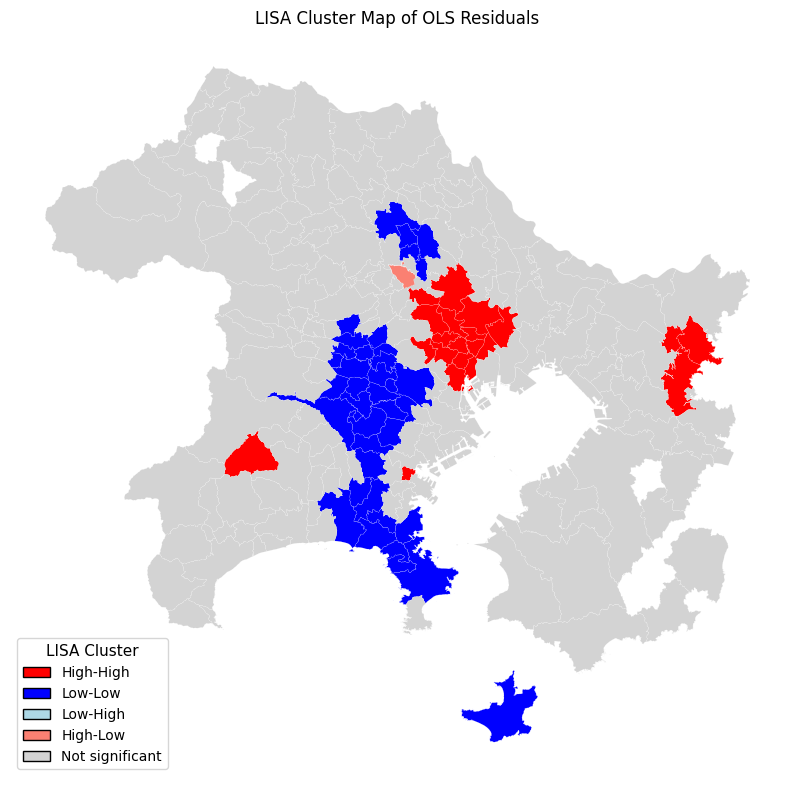

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

# 控制图例顺序
cluster_order = [
    "High-High",
    "Low-Low",
    "Low-High",
    "High-Low",
    "Not significant"
]

for cluster in cluster_order:
    gdf[gdf["lisa_cluster"] == cluster].plot(
        ax=ax,
        color=cluster_colors[cluster],
        edgecolor="white",
        linewidth=0.1
    )

# 手动构造图例
legend_handles = [
    Patch(facecolor=cluster_colors[cluster], edgecolor="black", label=cluster)
    for cluster in cluster_order
]

ax.legend(
    handles=legend_handles,
    title="LISA Cluster",
    loc="lower left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

ax.set_title("LISA Cluster Map of OLS Residuals")
ax.set_axis_off()

plt.savefig("../outputs/figures/lisa_cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
gdf[gdf["lisa_cluster"] == "High-High"][
    ["N03_001", "N03_004", "N03_005", "ols_resid", "lisa_p"]
].sort_values("ols_resid", ascending=False)

,N03_001,N03_004,N03_005,ols_resid,lisa_p
112,東京都,新宿区,,0.075370,0.012
124,東京都,豊島区,,0.054748,0.007
126,東京都,荒川区,,0.052576,0.013
103,千葉県,富里市,,0.052485,0.017
114,東京都,台東区,,0.041390,0.031
12,埼玉県,川口市,,0.032862,0.028
100,千葉県,八街市,,0.032802,0.030
125,東京都,北区,,0.032796,0.001
111,東京都,港区,,0.028359,0.020
29,埼玉県,戸田市,,0.021292,0.008


In [32]:
gdf[gdf["lisa_cluster"] == "Low-Low"][
    ["N03_001", "N03_004", "N03_005", "ols_resid", "lisa_p"]
].sort_values("ols_resid", ascending=True)

,N03_001,N03_004,N03_005,ols_resid,lisa_p
194,神奈川県,逗子市,,-0.024353,0.001
190,神奈川県,鎌倉市,,-0.023239,0.001
148,東京都,狛江市,,-0.023207,0.033
2,埼玉県,さいたま市,大宮区,-0.020402,0.017
204,神奈川県,葉山町,,-0.020369,0.011
174,神奈川県,横浜市,栄区,-0.019830,0.005
169,神奈川県,横浜市,戸塚区,-0.019685,0.019
177,神奈川県,横浜市,都筑区,-0.018879,0.018
183,神奈川県,川崎市,宮前区,-0.018257,0.007
175,神奈川県,横浜市,泉区,-0.018118,0.017


## LISA-based interpretation of OLS residuals

The LISA cluster map shows that OLS residuals are not only globally autocorrelated, but also locally structured in clear spatial clusters.

Several High-High clusters appear in the eastern and northeastern parts of the Tokyo metropolitan mainland area, as well as in parts of the Chiba-side urban belt. In these areas, the baseline OLS model systematically underestimates the foreign population ratio. This suggests that additional local mechanisms, such as migrant networks, specific labor-market structures, or urban service concentrations, are not fully captured by the current two-variable model.

At the same time, large Low-Low clusters appear across the southwestern Tokyo–Kanagawa belt and some outer areas, where the OLS model systematically overestimates foreign population ratios. This implies that station accessibility and land price alone are insufficient to explain foreign population concentration in these municipalities.

Overall, the LISA results provide strong evidence of spatial heterogeneity and justify moving from a global OLS model to a spatially varying modeling framework such as MGWR.

In [33]:
gdf["lisa_cluster"].value_counts()

lisa_cluster
Not significant    158
Low-Low             38
High-High           21
High-Low             1
Name: count, dtype: int64

In [34]:
mgwr_df = gdf[[
    "N03_007", "N03_001", "N03_004", "N03_005",
    "foreign_ratio",
    "dist_to_station_m",
    "log_dist_to_station_m",
    "median_land_price_jpy",
    "log_median_land_price_jpy",
    "ols_resid",
    "lisa_cluster",
    "geometry"
]].copy()

print(mgwr_df.shape)
mgwr_df.head()

KeyError: "['dist_to_station_m', 'median_land_price_jpy'] not in index"

In [ ]:
print(gdf.columns.tolist())

['N03_007', 'N03_001', 'N03_004', 'N03_005', 'foreign_ratio', 'log_dist_to_station_m', 'log_median_land_price_jpy', 'ols_fitted', 'ols_resid', 'geometry', 'lisa_I', 'lisa_p', 'lisa_q', 'lisa_sig', 'lisa_cluster']


In [ ]:
mgwr_df = gdf[[
    "N03_007", "N03_001", "N03_004", "N03_005",
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "ols_resid",
    "lisa_cluster",
    "geometry"
]].copy()

print(mgwr_df.shape)
print(mgwr_df.crs)

(218, 10)
EPSG:6677


In [ ]:
mgwr_df = gdf[[
    "N03_007", "N03_001", "N03_004", "N03_005",
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "ols_resid",
    "lisa_cluster",
    "geometry"
]].copy()

print(mgwr_df.shape)
print(mgwr_df.crs)
mgwr_df.head()

(218, 10)
EPSG:6677


,N03_007,N03_001,N03_004,N03_005,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,ols_resid,lisa_cluster,geometry
0,11101,埼玉県,さいたま市,西区,0.015422,7.105491,11.678448,-0.014858,Not significant,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,0.018455,5.933088,12.061053,-0.017581,Low-Low,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,0.027177,2.982405,12.553206,-0.020402,Low-Low,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,0.021768,6.913789,11.608245,-0.008623,Low-Low,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,0.019989,4.556274,12.639480,-0.023614,Not significant,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


In [ ]:
mgwr_df[[
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy"
]].isna().sum()

foreign_ratio                0
log_dist_to_station_m        0
log_median_land_price_jpy    0
dtype: int64

In [ ]:
mgwr_geojson_path = data_raw / "tokyo_mgwr_ready.geojson"
mgwr_df.to_file(mgwr_geojson_path, driver="GeoJSON")

print(mgwr_geojson_path)
print(mgwr_geojson_path.exists())

e:\rsch\laborJapan\data_raw\tokyo_mgwr_ready.geojson
True


In [ ]:
mgwr_df.drop(columns="geometry").to_csv(
    data_raw / "tokyo_mgwr_ready.csv",
    index=False,
    encoding="utf-8-sig"
)

print((data_raw / "tokyo_mgwr_ready.csv").exists())

True
